# California Housing
## Spår A: Regression – Prediktera Median House Value
#### Azar Mohseni    


### Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### Ladda data

In [57]:
df = pd.read_csv('data/housing.csv')


print("Dataförstålelse och EDA")
print(f"\nDatasetstorlyek: {df.shape[0]} rader, {df.shape[1]} kolumner")
print(f"\nDatatyper:\n{df.dtypes}")
print(f"\nFörsta 5 rader:\n{df.head()}")
print(f"\nSaknade värden:\n{df.isnull().sum()}")
print(f"\nBeskrivande statistik:\n{df.describe()}")


Dataförstålelse och EDA

Datasetstorlyek: 20640 rader, 10 kolumner

Datatyper:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Första 5 rader:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0

### Hantera saknade värden

In [58]:

print("Hantering av saknade värden")

saknade = df.isnull().sum()
saknade_procent = (saknade / len(df)) * 100
print(f"\nSaknade värden:\n{pd.DataFrame({'Antal': saknade, 'Procent': saknade_procent})}")

df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

print(f"\nSaknade värden i total_bedrooms fyllda med median")
print(f"Saknade värden: {df.isnull().sum().sum()}")

Hantering av saknade värden

Saknade värden:
                    Antal   Procent
longitude               0  0.000000
latitude                0  0.000000
housing_median_age      0  0.000000
total_rooms             0  0.000000
total_bedrooms        207  1.002907
population              0  0.000000
households              0  0.000000
median_income           0  0.000000
median_house_value      0  0.000000
ocean_proximity         0  0.000000

Saknade värden i total_bedrooms fyllda med median
Saknade värden: 207


### Skapa nya features

Nya features skapade:
  - rooms_per_household
  - bedrooms_per_household
  - population_per_household

In [59]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_household'] = df['total_bedrooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']

### EDA

### Visualiseringar

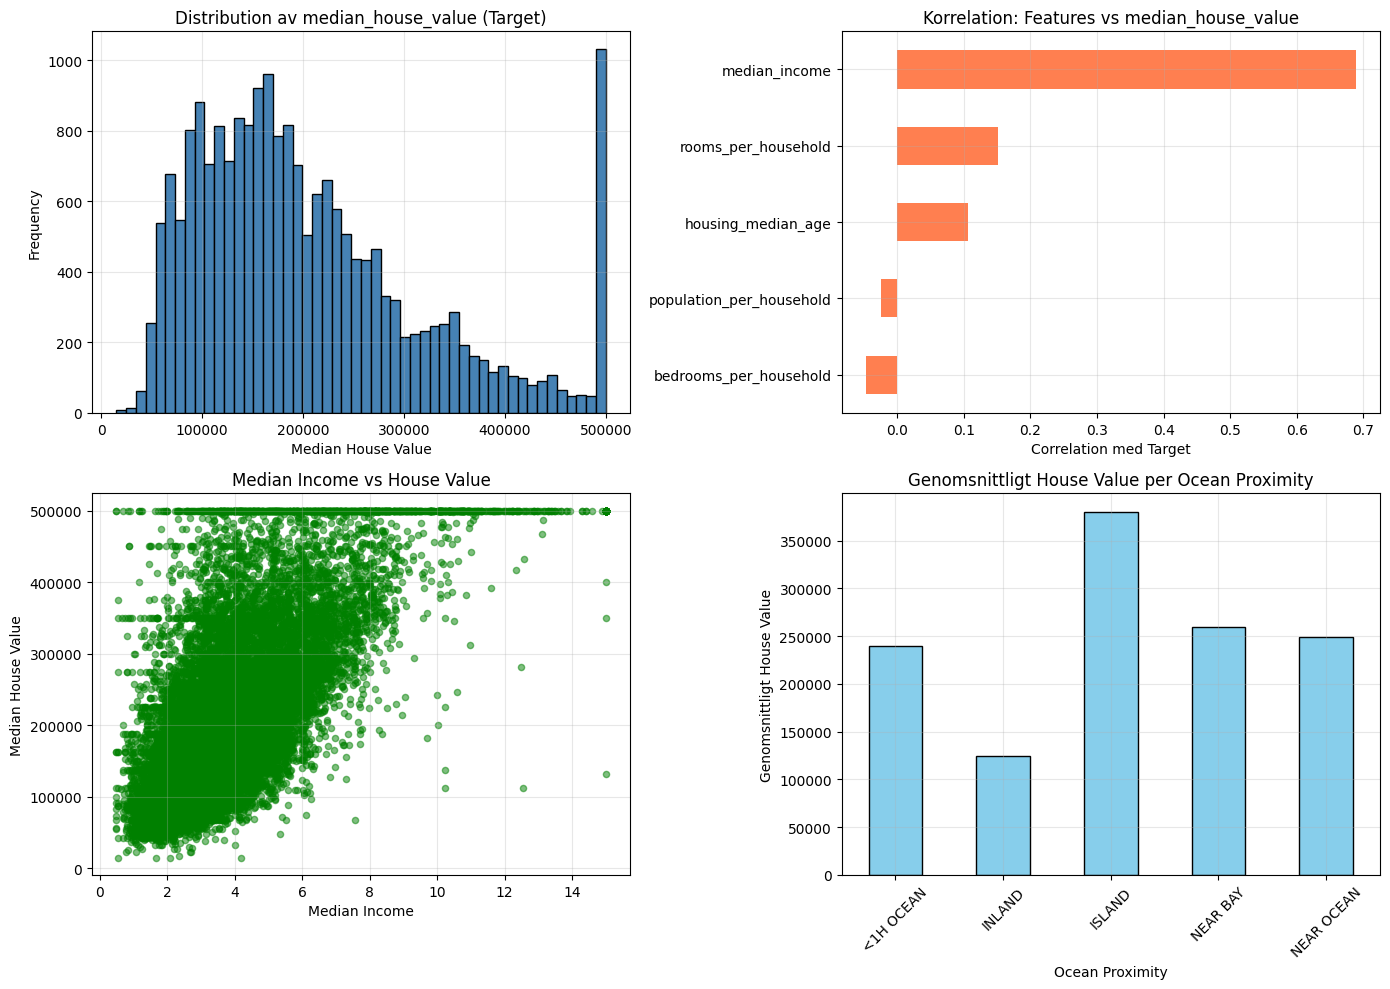

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Figur 1: Target-variabel distribution
axes[0, 0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Median House Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution av median_house_value (Target)')
axes[0, 0].grid(alpha=0.3)

# Figur 2: Korrelation mellan toppfeatures och target
top_features = ['median_income', 'rooms_per_household', 'bedrooms_per_household', 
                'population_per_household', 'housing_median_age']
correlations = df[top_features + ['median_house_value']].corr()['median_house_value'].drop('median_house_value')
correlations.sort_values().plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_xlabel('Correlation med Target')
axes[0, 1].set_title('Korrelation: Features vs median_house_value')
axes[0, 1].grid(alpha=0.3)

# Figur 3: Median Income vs House Value
axes[1, 0].scatter(df['median_income'], df['median_house_value'], alpha=0.5, s=20, color='green')
axes[1, 0].set_xlabel('Median Income')
axes[1, 0].set_ylabel('Median House Value')
axes[1, 0].set_title('Median Income vs House Value')
axes[1, 0].grid(alpha=0.3)

# Figur 4: Ocean Proximity distribution
ocean_value = df.groupby('ocean_proximity')['median_house_value'].mean()
ocean_value.plot(kind='bar', ax=axes[1, 1], color='skyblue', edgecolor='black')
axes[1, 1].set_xlabel('Ocean Proximity')
axes[1, 1].set_ylabel('Genomsnittligt House Value')
axes[1, 1].set_title('Genomsnittligt House Value per Ocean Proximity')
axes[1, 1].grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('EDA_visualisering.png', dpi=150, bbox_inches='tight')
plt.show()

### Split data - Train och test

### Train test split

In [61]:
# Separera features (X) och target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nTrain-set: {len(X_train) / len(X) * 100:.1f}% av datan")
print(f"Test-set: {len(X_test) / len(X) * 100:.1f}% av datan")


X_train shape: (16512, 12)
X_test shape: (4128, 12)
y_train shape: (16512,)
y_test shape: (4128,)

Train-set: 80.0% av datan
Test-set: 20.0% av datan


### Preprocessing - pipeline

In [62]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeriska features ({len(numerical_features)}): {numerical_features}")
print(f"Kategoriska features ({len(categorical_features)}): {categorical_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)


Numeriska features (11): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_household', 'population_per_household']
Kategoriska features (1): ['ocean_proximity']


### Modellering 

### Baseline + 2 modeller

In [63]:
# MODELL 1: Baseline, dummy Regressor
print("\nMODELL 1: Baseline")

from sklearn.dummy import DummyRegressor

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

# Cross-validation på training-set
cv_baseline = cross_val_score(
    baseline_pipeline, X_train, y_train, 
    cv=5, scoring='r2', n_jobs=-1
)

print(f"  CV R² (mean): {cv_baseline.mean():.4f} (+/- {cv_baseline.std():.4f})")
print(f"  CV fold-värden: {[f'{x:.4f}' for x in cv_baseline]}")

# MODELL 2: LINEAR REGRESSION
print("\nModell 2: Linear Regression")

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

cv_lr = cross_val_score(
    lr_pipeline, X_train, y_train, 
    cv=5, scoring='r2', n_jobs=-1
)

print(f"  CV R² (mean): {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")
print(f"  CV fold-värden: {[f'{x:.4f}' for x in cv_lr]}")

# MODELL 3: RANDOM FOREST
print("\nModell 3: Randon Forest")

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15))
])

cv_rf = cross_val_score(
    rf_pipeline, X_train, y_train, 
    cv=5, scoring='r2', n_jobs=-1
)

print(f"  CV R² (mean): {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
print(f"  CV fold-värden: {[f'{x:.4f}' for x in cv_rf]}")


MODELL 1: Baseline
  CV R² (mean): -0.0003 (+/- 0.0004)
  CV fold-värden: ['-0.0004', '-0.0000', '-0.0000', '-0.0011', '-0.0001']

Modell 2: Linear Regression
  CV R² (mean): 0.6496 (+/- 0.0124)
  CV fold-värden: ['0.6581', '0.6513', '0.6604', '0.6523', '0.6257']

Modell 3: Randon Forest
  CV R² (mean): 0.8055 (+/- 0.0094)
  CV fold-värden: ['0.8173', '0.7885', '0.8078', '0.8055', '0.8082']


### Jämför modeller 

In [64]:
comparison_df = pd.DataFrame({
   'Modell': ['Baseline', 'Linear Regression', 'Random Forest'],
   'CV R² (mean)': [cv_baseline.mean(), cv_lr.mean(), cv_rf.mean()],
   'CV R² (std)': [cv_baseline.std(), cv_lr.std(), cv_rf.std()],
})

print(f"\n{comparison_df.to_string(index=False)}")


           Modell  CV R² (mean)  CV R² (std)
         Baseline     -0.000317     0.000428
Linear Regression      0.649580     0.012414
    Random Forest      0.805454     0.009366


### Vald modell för optimering: Randon forest (högst R²)

### Hyperparameter - tuning

In [65]:
param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [2, 5],
}

print(f"\nGridSearch-parametrar:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBästa parametrar: {grid_search.best_params_}")
print(f"Bästa CV R² (GridSearch): {grid_search.best_score_:.4f}")


GridSearch-parametrar:
  model__n_estimators: [50, 100, 150]
  model__max_depth: [10, 15, 20]
  model__min_samples_split: [2, 5]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Bästa parametrar: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Bästa CV R² (GridSearch): 0.8087


### Slutlig Modell

In [66]:
best_model = grid_search.best_estimator_

y_pred_test = best_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"\nTest-set resultat:")
print(f"  MAE (Mean Absolute Error):  ${mae_test:,.0f}")
print(f"  RMSE (Root Mean Squared Error): ${rmse_test:,.0f}")
print(f"  R² Score: {r2_test:.4f}")

y_pred_train = best_model.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

print(f"\nTrain-set resultat (för jämförelse):")
print(f"  MAE: ${mae_train:,.0f}")
print(f"  R² Score: {r2_train:.4f}")


Test-set resultat:
  MAE (Mean Absolute Error):  $32,174
  RMSE (Root Mean Squared Error): $49,895
  R² Score: 0.8100

Train-set resultat (för jämförelse):
  MAE: $12,945
  R² Score: 0.9720


### Resultatsammanfattning

In [67]:
results_summary = pd.DataFrame({
    'Metrik': ['MAE', 'RMSE', 'R²'],
    'Värde': [f'${mae_test:,.0f}', f'${rmse_test:,.0f}', f'{r2_test:.4f}']
})

print(f"\nSlutlig Random Forest (optimerad):")
print(f"{results_summary.to_string(index=False)}")



Slutlig Random Forest (optimerad):
Metrik   Värde
   MAE $32,174
  RMSE $49,895
    R²  0.8100


- Modellen förklarar 81.0% av variansen i testdata
- Genomsnittligt prediktionsfel (MAE): $32,174

### Prediktioner vs Faktiska värden 

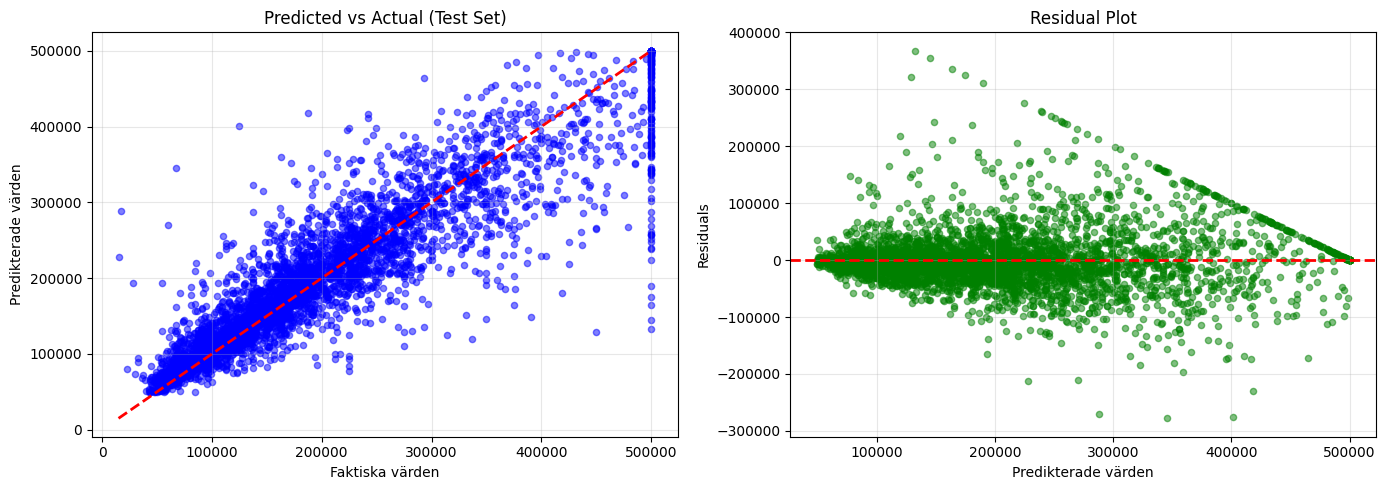

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Faktiska värden')
axes[0].set_ylabel('Predikterade värden')
axes[0].set_title('Predicted vs Actual (Test Set)')
axes[0].grid(alpha=0.3)

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=20, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predikterade värden')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Model_Results.png', dpi=150, bbox_inches='tight')
plt.show()

Resultat-visualiseringar sparade som 'Model_Results.png

### Rekomendation

Vald Modell: Random Forest

Motivering:
- Högsta R² på testdata: 0.8100
- Bättre än Linear Regression
- Klarar icke-linjära relationer mellan features och target
- MAE på $32,174 är acceptabelt för värdeprognos

Nästa steg:
1. Modellen kan användas för grova värdeprognos
2. Iterativ förbättring med mer data eller features
3. Regelbundna validationer för att detekat datadrift
